In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [30]:
box_img = cv.imread('../../../class.vision/images/box.png')
box_in_scene_img = cv.imread('../../../class.vision/images/box_in_scene.png')

salamat_img = cv.imread('../../images/salamat.png')
chips_packet_img = cv.imread('../../images/chips_packet.jpg')

## SIFT + BF.knn

(np.float64(-0.5), np.float64(835.5), np.float64(383.5), np.float64(-0.5))

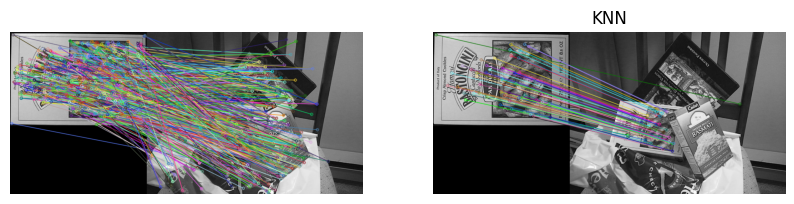

In [31]:
sift = cv.SIFT_create()
bf = cv.BFMatcher(cv.NORM_L2)

kp1, des1 = sift.detectAndCompute(box_img, None)
kp2, des2 = sift.detectAndCompute(box_in_scene_img, None)

matches = bf.match(des1, des2)
res1 = cv.drawMatches(box_img, kp1, box_in_scene_img, kp2, matches,None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

matches = bf.knnMatch(des1, des2,k=2)
best_matches = []

for m1,m2 in matches:
    if m1.distance < 0.7*m2.distance:
        best_matches.append([m1])

res2 = cv.drawMatchesKnn(box_img, kp1, box_in_scene_img, kp2, best_matches,None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(10,6))
plt.subplot(121); plt.imshow(res1[...,::-1]); plt.title(""); plt.axis('off')
plt.subplot(122); plt.imshow(res2[...,::-1]); plt.title("KNN"); plt.axis('off')

## SIFT and BF.knn on custom image

(np.float64(-0.5), np.float64(1104.5), np.float64(631.5), np.float64(-0.5))

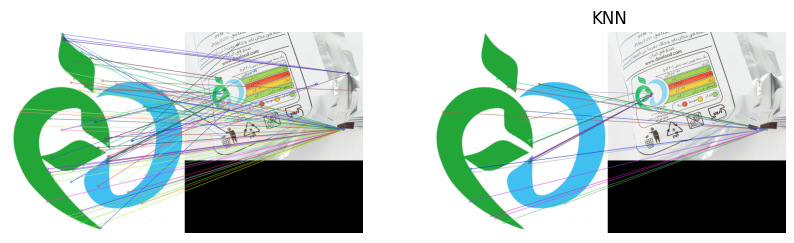

In [32]:
kp1, des1 = sift.detectAndCompute(salamat_img, None)
kp2, des2 = sift.detectAndCompute(chips_packet_img, None)

matches = bf.match(des1, des2)
res1 = cv.drawMatches(salamat_img, kp1, chips_packet_img, kp2, matches,None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

matches = bf.knnMatch(des1, des2,k=2)
best_matches = []

for m1,m2 in matches:
    if m1.distance < 0.7*m2.distance:
        best_matches.append([m1])

res2 = cv.drawMatchesKnn(salamat_img, kp1, chips_packet_img, kp2, best_matches,None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(10,6))
plt.subplot(121); plt.imshow(res1[...,::-1]); plt.title(""); plt.axis('off')
plt.subplot(122); plt.imshow(res2[...,::-1]); plt.title("KNN"); plt.axis('off')

## SIFT and FLANN on custom image

(np.float64(-0.5), np.float64(1104.5), np.float64(631.5), np.float64(-0.5))

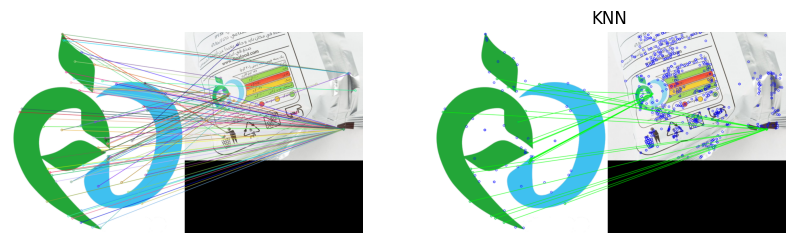

In [33]:
kp1, des1 = sift.detectAndCompute(salamat_img, None)
kp2, des2 = sift.detectAndCompute(chips_packet_img, None)

# FLANN parameters
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv.FlannBasedMatcher(index_params,search_params)

matches = flann.match(des1, des2)
res1 = cv.drawMatches(salamat_img, kp1, chips_packet_img, kp2, matches,None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

matches = flann.knnMatch(des1, des2,k=2)
matches_mask = np.zeros_like(matches, dtype=np.uint8)

for idx, (m1,m2) in enumerate(matches):
    if m1.distance < 0.7*m2.distance:
        matches_mask[idx, 0] = 1

draw_params = dict(matchColor = (0,255,0),
                   singlePointColor = (255,0,0),
                   matchesMask = matches_mask,
                   flags = cv.DrawMatchesFlags_DEFAULT)

res2 = cv.drawMatchesKnn(salamat_img, kp1, chips_packet_img, kp2, matches,None, **draw_params)

plt.figure(figsize=(10,6))
plt.subplot(121); plt.imshow(res1[...,::-1]); plt.title(""); plt.axis('off')
plt.subplot(122); plt.imshow(res2[...,::-1]); plt.title("KNN"); plt.axis('off')